# Sprint 3 — Hyperparameter Tuning & MLflow Experiment Tracking

## Overview
This notebook covers:
- **HyperOpt**: Bayesian hyperparameter optimization for XGBoost and LSTM
- **MLflow**: Experiment tracking, metric logging, and model comparison
- **Champion Model**: Saving the best model for deployment in Sprint 4

**Dataset**: Corporación Favorita — Store 44, Item 1047679
**Test period**: Last 20% of data (chronological split)


In [4]:
import subprocess

print("Installing with --user flag...")
result = subprocess.run(
    ['pip', 'install', 'hyperopt', 'mlflow', '--user'],
    capture_output=True, text=True
)
print(result.stdout[-1000:] if len(result.stdout) > 1000 else result.stdout)
if result.stderr:
    print("Errors:", result.stderr[-500:])
print("Done!")


Installing with --user flag...
ied: anyio<5,>=3.6.2 in c:\users\armin\appdata\roaming\python\python39\site-packages (from starlette<1.0.0,>=0.40.0->fastapi<1->mlflow-skinny==3.1.4->mlflow) (4.12.1)

Done!


## 1. Imports & Data Loading

In [6]:
import sys
import os

# Add user site-packages to path (where --user packages are installed)
user_site = os.path.expanduser('~\\AppData\\Roaming\\Python\\Python39\\site-packages')
if user_site not in sys.path:
    sys.path.insert(0, user_site)
    print(f"Added to path: {user_site}")

# Test imports
try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
    print("HyperOpt: OK")
except ImportError as e:
    print(f"HyperOpt ERROR: {e}")

try:
    import mlflow
    print(f"MLflow: OK (v{mlflow.__version__})")
except ImportError as e:
    print(f"MLflow ERROR: {e}")


HyperOpt: OK
MLflow: OK (v3.1.4)


In [7]:
# === 1. IMPORTS & DATA LOADING ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ML libraries
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# HyperOpt
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# PyTorch (for LSTM)
import torch
import torch.nn as nn

# MLflow
import mlflow
import mlflow.xgboost

plt.style.use('dark_background')
print("All libraries imported successfully!")
print(f"  XGBoost: {xgb.__version__}")
print(f"  MLflow:  {mlflow.__version__}")
print(f"  PyTorch: {torch.__version__}")

# ── Load pre-cleaned time series ──────────────────────────────
ts_data = pd.read_csv('ts_store44_item1047679.csv',
                      index_col='date', parse_dates=True)
ts_data = ts_data.asfreq('D')

# ── Train/Test split (80/20 chronological) ────────────────────
split_idx = int(len(ts_data) * 0.8)
train = ts_data.iloc[:split_idx]
test  = ts_data.iloc[split_idx:]

print(f"\nData loaded: {len(ts_data)} days total")
print(f"  Train: {len(train)} days ({train.index[0].date()} → {train.index[-1].date()})")
print(f"  Test:  {len(test)} days  ({test.index[0].date()} → {test.index[-1].date()})")

All libraries imported successfully!
  XGBoost: 2.1.4
  MLflow:  3.1.4
  PyTorch: 2.8.0+cpu

Data loaded: 1687 days total
  Train: 1349 days (2013-01-02 → 2016-09-11)
  Test:  338 days  (2016-09-12 → 2017-08-15)


## 2. Feature Engineering

In [9]:
# === 3. FEATURE ENGINEERING ===
# Reusable function — same features as Sprint 2 for fair comparison

def create_features(df):
    """Create calendar, lag and rolling features for tree-based models."""
    df = df.copy()
    df['day_of_week']    = df.index.dayofweek
    df['month']          = df.index.month
    df['day_of_month']   = df.index.day
    df['week_of_year']   = df.index.isocalendar().week.astype(int)
    df['is_weekend']     = (df.index.dayofweek >= 5).astype(int)
    df['quarter']        = df.index.quarter
    df['lag_1']          = df['unit_sales'].shift(1)
    df['lag_7']          = df['unit_sales'].shift(7)
    df['lag_14']         = df['unit_sales'].shift(14)
    df['lag_30']         = df['unit_sales'].shift(30)
    df['rolling_mean_7'] = df['unit_sales'].shift(1).rolling(7).mean()
    df['rolling_std_7']  = df['unit_sales'].shift(1).rolling(7).std()
    df['rolling_mean_14']= df['unit_sales'].shift(1).rolling(14).mean()
    df.dropna(inplace=True)
    return df

df_feat = create_features(ts_data)

FEATURES = [c for c in df_feat.columns if c != 'unit_sales']
TARGET   = 'unit_sales'

# Chronological split
split_idx = int(len(df_feat) * 0.8)
X_train = df_feat.iloc[:split_idx][FEATURES]
y_train = df_feat.iloc[:split_idx][TARGET]
X_test  = df_feat.iloc[split_idx:][FEATURES]
y_test  = df_feat.iloc[split_idx:][TARGET]

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")


Features (13): ['day_of_week', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'quarter', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14']

Train: (1325, 13)  |  Test: (332, 13)


## 3. MLflow Setup & Helper Functions

In [10]:
# === 3. MLFLOW SETUP & HELPER FUNCTIONS ===

# Set local tracking URI (saves to mlruns/ folder in project directory)
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Forecast_XGB_LSTM")
print("MLflow experiment: 'Forecast_XGB_LSTM'")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

# ── Metric calculation function ────────────────────────────────
def forecast_metrics(y_true, y_pred):
    """Compute MAE, Bias, MAD, rMAD, MAPE, RMSE."""
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    errors     = y_true - y_pred
    abs_errors = np.abs(errors)
    mae   = abs_errors.mean()
    bias  = errors.mean()
    rmse  = np.sqrt((errors ** 2).mean())
    mad   = np.abs(y_true - y_true.mean()).mean()
    rmad  = mae / mad if mad else np.nan
    mape  = np.nanmean(np.abs(errors / np.where(y_true == 0, np.nan, y_true))) * 100
    return {"MAE": mae, "Bias": bias, "MAD": mad,
            "rMAD": rmad, "MAPE": mape, "RMSE": rmse}

# ── Plot saver ─────────────────────────────────────────────────
def save_forecast_plot(y_true, y_pred, path, title="Forecast vs Actual"):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(np.array(y_true),  label="Actual",    color='white',  lw=1.5, alpha=0.8)
    ax.plot(np.array(y_pred),  label="Predicted", color='#00BFFF', lw=1.5)
    ax.set_title(title, fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(path, dpi=100, bbox_inches='tight')
    plt.close()

# ── MLflow run logger ──────────────────────────────────────────
def log_candidate(run_name, params, y_true, y_pred, fig_name, model=None):
    """Log a single model run: params, metrics, forecast plot."""
    with mlflow.start_run(run_name=run_name, nested=True):
        mlflow.log_params(params)
        metrics = forecast_metrics(y_true, y_pred)
        mlflow.log_metrics(metrics)
        save_forecast_plot(y_true, y_pred, fig_name, title=run_name)
        mlflow.log_artifact(fig_name)
        if model is not None and isinstance(model, XGBRegressor):
            mlflow.xgboost.log_model(model, name="model")
    return metrics

print("\nHelper functions defined:")
print("  forecast_metrics() — MAE, Bias, MAD, rMAD, MAPE, RMSE")
print("  save_forecast_plot() — saves PNG forecast chart")
print("  log_candidate() — logs run to MLflow")


MLflow experiment: 'Forecast_XGB_LSTM'
Tracking URI: file:./mlruns

Helper functions defined:
  forecast_metrics() — MAE, Bias, MAD, rMAD, MAPE, RMSE
  save_forecast_plot() — saves PNG forecast chart
  log_candidate() — logs run to MLflow


## 4. Baseline XGBoost (Default Parameters)
Establishing a baseline before hyperparameter tuning to measure improvement.

=== BASELINE XGBoost (Default Parameters) ===
  MAE   : 136.24
  Bias  : -94.35
  MAD   : 122.68
  rMAD  : 1.11
  MAPE  : 48.68
  RMSE  : 165.40


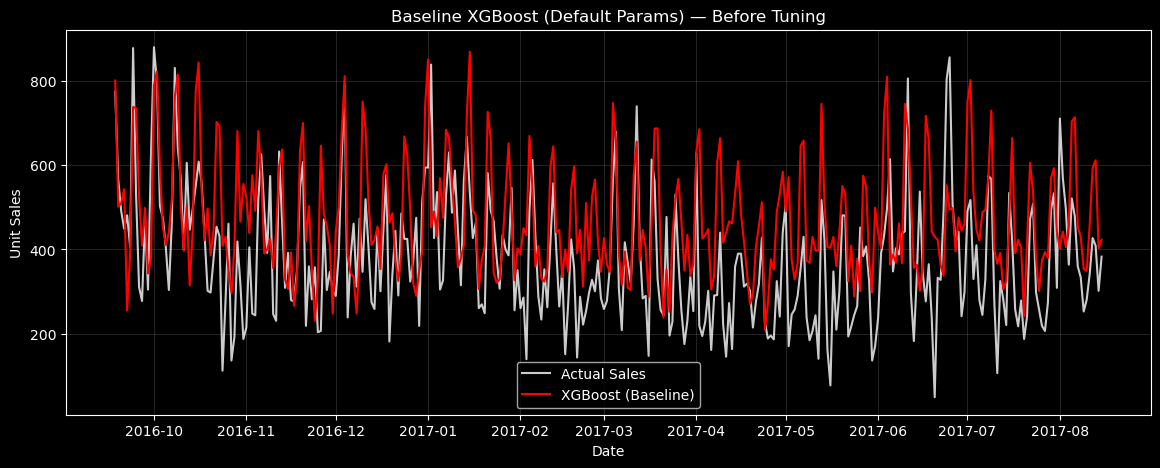

In [11]:
# === 4. BASELINE XGBOOST (DEFAULT PARAMETERS) ===
# Train with default params — no tuning — to establish a comparison baseline

baseline_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
baseline_xgb.fit(X_train, y_train)
baseline_preds = baseline_xgb.predict(X_test)
baseline_metrics = forecast_metrics(y_test.values, baseline_preds)

print("=== BASELINE XGBoost (Default Parameters) ===")
for k, v in baseline_metrics.items():
    print(f"  {k:6s}: {v:,.2f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values,    label='Actual Sales',       color='white', alpha=0.8)
plt.plot(y_test.index, baseline_preds,   label='XGBoost (Baseline)', color='red',   lw=1.5)
plt.title('Baseline XGBoost (Default Params) — Before Tuning')
plt.xlabel('Date'); plt.ylabel('Unit Sales')
plt.legend(); plt.grid(True, alpha=0.2); plt.show()


## 4. XGBoost — HyperOpt Hyperparameter Tuning

In [12]:
# === 4. XGBOOST — HYPEROPT TUNING ===
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# ── Define search space ────────────────────────────────────────
xgb_space = {
    'n_estimators':    hp.choice('n_estimators',  [100, 200, 300, 500]),
    'max_depth':       hp.choice('max_depth',     [3, 5, 7]),
    'learning_rate':   hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.3]),
    'subsample':       hp.uniform('subsample',    0.6, 1.0),
    'colsample_bytree':hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_weight':hp.choice('min_child_weight', [1, 3, 5]),
}

# ── TimeSeriesSplit for cross-validation ──────────────────────
tscv = TimeSeriesSplit(n_splits=5)

# ── Objective function ─────────────────────────────────────────
def xgb_objective(params):
    """HyperOpt minimizes this function — we return CV MAE."""
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **params
    )
    mae_scores = []
    for tr_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr, verbose=False)
        preds = model.predict(X_val)
        mae_scores.append(mean_absolute_error(y_val, preds))
    return {'loss': np.mean(mae_scores), 'status': STATUS_OK}

# ── Run HyperOpt search ────────────────────────────────────────
print("Running HyperOpt for XGBoost (50 trials)...")
xgb_trials = Trials()
xgb_best = fmin(
    fn=xgb_objective,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=xgb_trials,
    verbose=False
)

# Map choice indices back to actual values
n_est_vals = [100, 200, 300, 500]
depth_vals = [3, 5, 7]
lr_vals    = [0.01, 0.05, 0.1, 0.3]
mcw_vals   = [1, 3, 5]

best_xgb_params = {
    'n_estimators':     n_est_vals[xgb_best['n_estimators']],
    'max_depth':        depth_vals[xgb_best['max_depth']],
    'learning_rate':    lr_vals[xgb_best['learning_rate']],
    'subsample':        round(xgb_best['subsample'], 3),
    'colsample_bytree': round(xgb_best['colsample_bytree'], 3),
    'min_child_weight': mcw_vals[xgb_best['min_child_weight']],
}

print("\n=== BEST XGBoost PARAMETERS (HyperOpt) ===")
for k, v in best_xgb_params.items():
    print(f"  {k}: {v}")


Running HyperOpt for XGBoost (50 trials)...

=== BEST XGBoost PARAMETERS (HyperOpt) ===
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.05
  subsample: 0.986
  colsample_bytree: 0.838
  min_child_weight: 1


## 5. XGBoost — Train Best Model & Log to MLflow

=== TUNED XGBoost RESULTS ===
  MAE   : 127.50
  Bias  : -90.75
  MAD   : 122.68
  rMAD  : 1.04
  MAPE  : 46.47
  RMSE  : 152.04


2026/05/04 23:13:59 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/05/04 23:14:05 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pi

  Logged 10/50 trials...


2026/05/04 23:14:55 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\armin\AppData\Local\Temp\tmpqc3akort\model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/05/04 23:14:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/04 23:15:00 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\armin\AppData\Local\Temp\tmpkrvq4p1i\model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/05/04 23:15:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/04 23:

  Logged 20/50 trials...


...

  Logged 40/50 trials...


2026/05/04 23:17:25 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\armin\AppData\Local\Temp\tmpj_eaxyc_\model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/05/04 23:17:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/04 23:17:29 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\armin\AppData\Local\Temp\tmpllbdm1tw\model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/05/04 23:17:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/04 23:

  Logged 50/50 trials...


2026/05/04 23:18:13 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\armin\AppData\Local\Temp\tmp2sc77h6v\model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/05/04 23:18:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✓ XGBoost logged to MLflow (50 trials + best model)


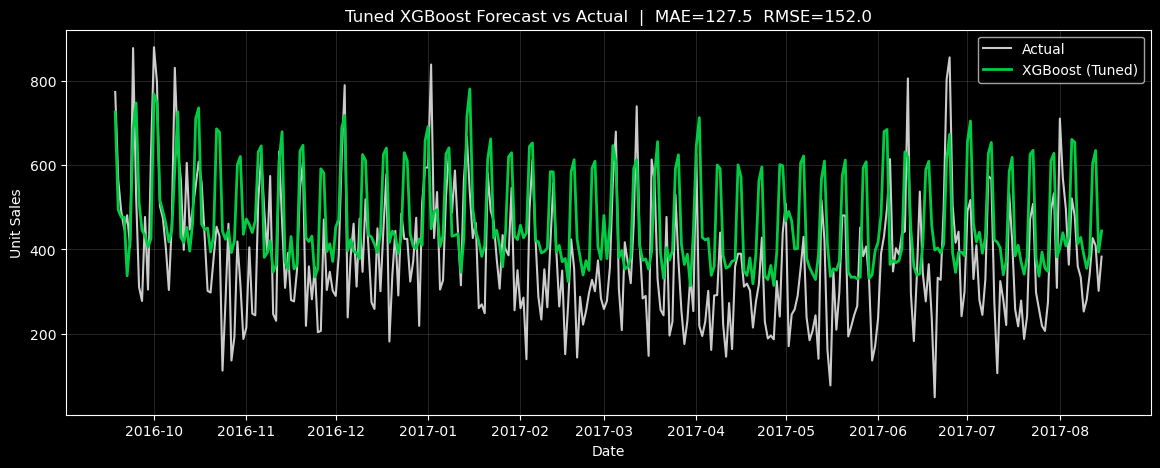

In [13]:
# === 5. TRAIN BEST XGBOOST & LOG TO MLFLOW ===

# ── Train final model with best parameters ─────────────────────
best_xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_xgb_params
)
best_xgb.fit(X_train, y_train)
xgb_preds = best_xgb.predict(X_test)

# ── Evaluate ───────────────────────────────────────────────────
xgb_metrics = forecast_metrics(y_test.values, xgb_preds)

print("=== TUNED XGBoost RESULTS ===")
for k, v in xgb_metrics.items():
    print(f"  {k:6s}: {v:,.2f}")

# ── Log to MLflow ──────────────────────────────────────────────
with mlflow.start_run(run_name="XGB_HyperOpt_Search"):
    # Log all 50 trials as nested runs
    for i, trial in enumerate(xgb_trials.trials):
        trial_params = {
            'model_type':       'XGBoost',
            'n_estimators':     n_est_vals[trial['misc']['vals']['n_estimators'][0]],
            'max_depth':        depth_vals[trial['misc']['vals']['max_depth'][0]],
            'learning_rate':    lr_vals[trial['misc']['vals']['learning_rate'][0]],
            'subsample':        round(trial['misc']['vals']['subsample'][0], 3),
            'colsample_bytree': round(trial['misc']['vals']['colsample_bytree'][0], 3),
            'min_child_weight': mcw_vals[trial['misc']['vals']['min_child_weight'][0]],
        }
        trial_model = XGBRegressor(
            objective='reg:squarederror', random_state=42,
            n_estimators=trial_params['n_estimators'],
            max_depth=trial_params['max_depth'],
            learning_rate=trial_params['learning_rate'],
            subsample=trial_params['subsample'],
            colsample_bytree=trial_params['colsample_bytree'],
            min_child_weight=trial_params['min_child_weight'],
        )
        trial_model.fit(X_train, y_train)
        trial_preds = trial_model.predict(X_test)
        log_candidate(
            run_name=f"xgb_trial_{i:02d}",
            params=trial_params,
            y_true=y_test.values,
            y_pred=trial_preds,
            fig_name=f"xgb_trial_{i:02d}.png",
            model=trial_model
        )
        if (i + 1) % 10 == 0:
            print(f"  Logged {i+1}/50 trials...")

    # Log best run summary
    mlflow.log_params({**{'model_type': 'XGBoost_BEST'}, **best_xgb_params})
    mlflow.log_metrics(xgb_metrics)
    save_forecast_plot(y_test.values, xgb_preds, "xgb_best.png",
                       title=f"XGBoost Best — MAE={xgb_metrics['MAE']:.1f}")
    mlflow.log_artifact("xgb_best.png")
    mlflow.xgboost.log_model(best_xgb, name="xgb_best_model")

print("\n✓ XGBoost logged to MLflow (50 trials + best model)")

# ── Visualization ──────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values,  label='Actual',          color='white',   alpha=0.8)
plt.plot(y_test.index, xgb_preds,      label='XGBoost (Tuned)', color='#00CC44', lw=2)
plt.title(f'Tuned XGBoost Forecast vs Actual  |  MAE={xgb_metrics["MAE"]:.1f}  RMSE={xgb_metrics["RMSE"]:.1f}')
plt.xlabel('Date'); plt.ylabel('Unit Sales')
plt.legend(); plt.grid(True, alpha=0.2); plt.show()


## 6. LSTM — HyperOpt Hyperparameter Tuning

In [14]:
# === 6. LSTM — HYPEROPT TUNING ===

# ── Scale data for LSTM ────────────────────────────────────────
scaler_lstm = StandardScaler()
train_scaled = scaler_lstm.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled  = scaler_lstm.transform(test.values.reshape(-1, 1)).flatten()

# ── Sliding window helper ──────────────────────────────────────
def make_sequences(arr, seq_len):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i : i + seq_len])
        y.append(arr[i + seq_len])
    return (torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1),
            torch.tensor(np.array(y), dtype=torch.float32))

# ── LSTM model factory ─────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)

# ── HyperOpt objective for LSTM ────────────────────────────────
def lstm_objective(params):
    seq_len    = int(params['seq_len'])
    hidden     = int(params['hidden_size'])
    num_layers = int(params['num_layers'])
    lr         = params['lr']
    epochs     = 20

    X_tr, y_tr = make_sequences(train_scaled, seq_len)
    X_te, y_te = make_sequences(test_scaled,  seq_len)

    torch.manual_seed(42)
    model = LSTMModel(hidden, num_layers)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit  = nn.MSELoss()

    # Quick training
    model.train()
    for _ in range(epochs):
        for i in range(0, len(X_tr), 32):
            xb, yb = X_tr[i:i+32], y_tr[i:i+32]
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds_sc = model(X_te).numpy()

    preds = scaler_lstm.inverse_transform(preds_sc.reshape(-1,1)).flatten()
    true  = test.values[seq_len:]
    mae   = mean_absolute_error(true, preds)
    return {'loss': mae, 'status': STATUS_OK,
            'preds': preds, 'true': true, 'model': model, 'seq_len': seq_len}

# ── Search space ───────────────────────────────────────────────
lstm_space = {
    'seq_len':     hp.choice('seq_len',     [14, 30, 60]),
    'hidden_size': hp.choice('hidden_size', [32, 64, 128]),
    'num_layers':  hp.choice('num_layers',  [1, 2]),
    'lr':          hp.choice('lr',          [0.001, 0.005, 0.01]),
}

print("Running HyperOpt for LSTM (24 trials)...")
lstm_trials = Trials()
lstm_best = fmin(
    fn=lstm_objective,
    space=lstm_space,
    algo=tpe.suggest,
    max_evals=24,
    trials=lstm_trials,
    verbose=False
)

# Map indices to values
seq_vals    = [14, 30, 60]
hidden_vals = [32, 64, 128]
layer_vals  = [1, 2]
lr_vals_l   = [0.001, 0.005, 0.01]

best_lstm_params = {
    'seq_len':     seq_vals[lstm_best['seq_len']],
    'hidden_size': hidden_vals[lstm_best['hidden_size']],
    'num_layers':  layer_vals[lstm_best['num_layers']],
    'lr':          lr_vals_l[lstm_best['lr']],
}

print("\n=== BEST LSTM PARAMETERS (HyperOpt) ===")
for k, v in best_lstm_params.items():
    print(f"  {k}: {v}")


Running HyperOpt for LSTM (24 trials)...

=== BEST LSTM PARAMETERS (HyperOpt) ===
  seq_len: 14
  hidden_size: 128
  num_layers: 1
  lr: 0.005


## 7. LSTM — Train Best Model & Log to MLflow

Training final LSTM: seq=14, hidden=128, layers=1, lr=0.005
  Epoch 10/40 done
  Epoch 20/40 done
  Epoch 30/40 done
  Epoch 40/40 done

=== TUNED LSTM RESULTS ===
  MAE   : 155.29
  Bias  : -120.82
  MAD   : 120.37
  rMAD  : 1.29
  MAPE  : 57.20
  RMSE  : 188.34
  Logged 8/24 LSTM trials...
  Logged 16/24 LSTM trials...
  Logged 24/24 LSTM trials...

✓ LSTM logged to MLflow (24 trials + best model)


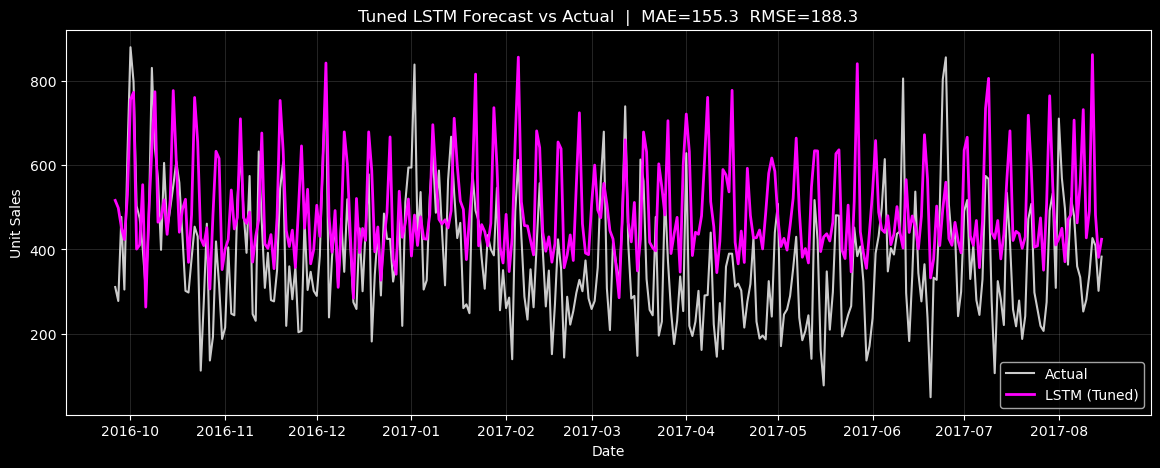

In [15]:
# === 7. TRAIN BEST LSTM & LOG TO MLFLOW ===

# ── Train final LSTM with best parameters ─────────────────────
best_seq    = best_lstm_params['seq_len']
best_hidden = best_lstm_params['hidden_size']
best_layers = best_lstm_params['num_layers']
best_lr     = best_lstm_params['lr']
EPOCHS_FINAL = 40  # more epochs for final model

X_train_lstm, y_train_lstm = make_sequences(train_scaled, best_seq)
X_test_lstm,  y_test_lstm  = make_sequences(test_scaled,  best_seq)

torch.manual_seed(42)
best_lstm = LSTMModel(best_hidden, best_layers)
optimizer = torch.optim.Adam(best_lstm.parameters(), lr=best_lr)
criterion = nn.MSELoss()

print(f"Training final LSTM: seq={best_seq}, hidden={best_hidden}, layers={best_layers}, lr={best_lr}")
best_lstm.train()
for epoch in range(EPOCHS_FINAL):
    for i in range(0, len(X_train_lstm), 32):
        xb, yb = X_train_lstm[i:i+32], y_train_lstm[i:i+32]
        optimizer.zero_grad()
        criterion(best_lstm(xb), yb).backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_FINAL} done")

# ── Predictions ────────────────────────────────────────────────
best_lstm.eval()
with torch.no_grad():
    lstm_preds_sc = best_lstm(X_test_lstm).numpy()

lstm_preds   = scaler_lstm.inverse_transform(lstm_preds_sc.reshape(-1,1)).flatten()
lstm_true    = test.values[best_seq:]
lstm_metrics = forecast_metrics(lstm_true, lstm_preds)

print("\n=== TUNED LSTM RESULTS ===")
for k, v in lstm_metrics.items():
    print(f"  {k:6s}: {v:,.2f}")

# ── Log all LSTM trials to MLflow ──────────────────────────────
with mlflow.start_run(run_name="LSTM_HyperOpt_Search"):
    for i, trial in enumerate(lstm_trials.trials):
        if trial['result']['status'] != STATUS_OK:
            continue
        t_seq    = seq_vals[trial['misc']['vals']['seq_len'][0]]
        t_hidden = hidden_vals[trial['misc']['vals']['hidden_size'][0]]
        t_layers = layer_vals[trial['misc']['vals']['num_layers'][0]]
        t_lr     = lr_vals_l[trial['misc']['vals']['lr'][0]]

        # Re-run to get predictions for this trial
        X_tr_t, y_tr_t = make_sequences(train_scaled, t_seq)
        X_te_t, _      = make_sequences(test_scaled,  t_seq)
        torch.manual_seed(42)
        t_model = LSTMModel(t_hidden, t_layers)
        t_opt   = torch.optim.Adam(t_model.parameters(), lr=t_lr)
        t_model.train()
        for _ in range(20):
            for j in range(0, len(X_tr_t), 32):
                xb, yb = X_tr_t[j:j+32], y_tr_t[j:j+32]
                t_opt.zero_grad()
                criterion(t_model(xb), yb).backward()
                t_opt.step()
        t_model.eval()
        with torch.no_grad():
            t_preds_sc = t_model(X_te_t).numpy()
        t_preds = scaler_lstm.inverse_transform(t_preds_sc.reshape(-1,1)).flatten()
        t_true  = test.values[t_seq:]

        log_candidate(
            run_name=f"lstm_trial_{i:02d}",
            params={"model_type": "LSTM", "seq_len": t_seq,
                    "hidden_size": t_hidden, "num_layers": t_layers,
                    "lr": t_lr, "epochs": 20},
            y_true=t_true, y_pred=t_preds,
            fig_name=f"lstm_trial_{i:02d}.png"
        )
        if (i + 1) % 8 == 0:
            print(f"  Logged {i+1}/24 LSTM trials...")

    # Log best LSTM
    mlflow.log_params({**{"model_type": "LSTM_BEST"}, **best_lstm_params, "epochs": EPOCHS_FINAL})
    mlflow.log_metrics(lstm_metrics)
    save_forecast_plot(lstm_true, lstm_preds, "lstm_best.png",
                       title=f"LSTM Best — MAE={lstm_metrics['MAE']:.1f}")
    mlflow.log_artifact("lstm_best.png")
    # Save PyTorch model
    torch.save(best_lstm.state_dict(), "lstm_best_model.pth")
    mlflow.log_artifact("lstm_best_model.pth")

print("\n✓ LSTM logged to MLflow (24 trials + best model)")

# ── Visualization ──────────────────────────────────────────────
test_index_lstm = test.index[best_seq:]
plt.figure(figsize=(14, 5))
plt.plot(test_index_lstm, lstm_true,  label='Actual',         color='white',   alpha=0.8)
plt.plot(test_index_lstm, lstm_preds, label='LSTM (Tuned)',   color='magenta', lw=2)
plt.title(f'Tuned LSTM Forecast vs Actual  |  MAE={lstm_metrics["MAE"]:.1f}  RMSE={lstm_metrics["RMSE"]:.1f}')
plt.xlabel('Date'); plt.ylabel('Unit Sales')
plt.legend(); plt.grid(True, alpha=0.2); plt.show()


## 8. Final Model Comparison — All Tuned Models

     SPRINT 3 — FINAL MODEL COMPARISON

Model                               MAE     RMSE     MAPE   vs Sprint2 MAE
----------------------------------------------------------------------
  ARIMA(1,0,1)                   181.18   211.01   70.66%       (baseline)
  SARIMA(1,0,1)(1,1,1,7)         196.75   224.05   72.11%       (baseline)
  XGBoost (Sprint 2)             135.85   163.68   49.63%       (baseline)
  LSTM (Sprint 2)                142.21   166.05   66.21%       (baseline)

  XGBoost (HyperOpt)             127.50   152.04   46.47%            +6.1% ← CHAMPION
  LSTM (HyperOpt)                155.29   188.34   57.20%            -9.2%
----------------------------------------------------------------------


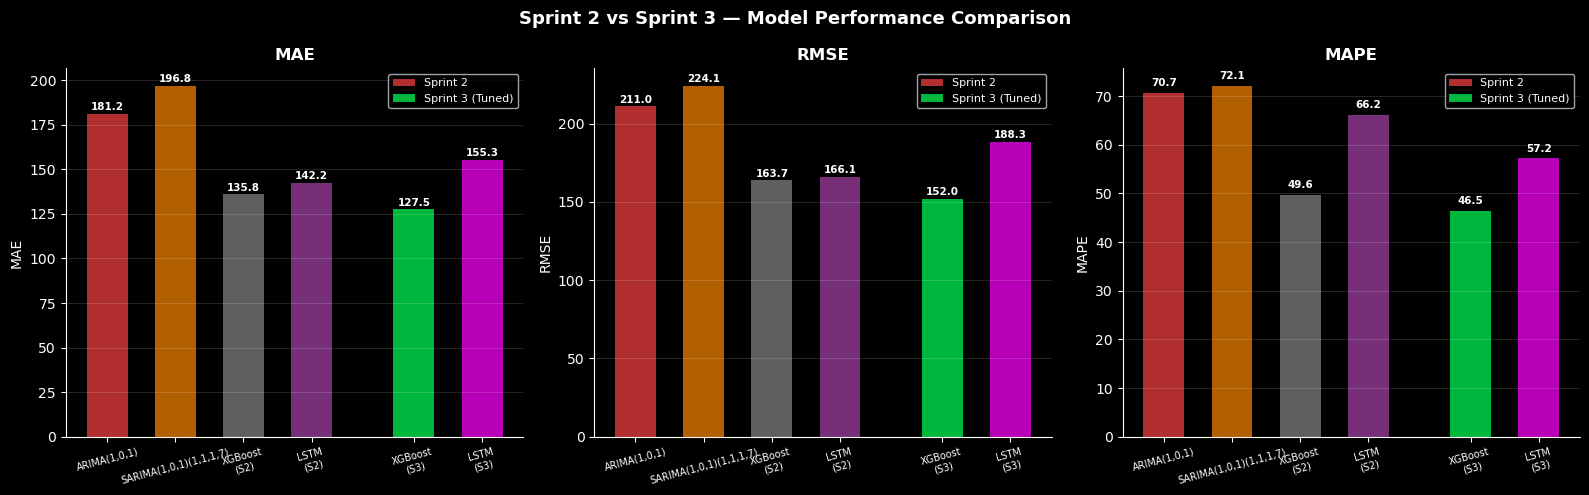


✓ Sprint 3 Complete!
  Champion model: XGBoost (HyperOpt)
  Best MAE: 127.50
  Next: Save champion model → Sprint 4 (deployment)


In [16]:
# === 8. FINAL MODEL COMPARISON — ALL TUNED MODELS ===

# Sprint 2 baseline results (from previous notebook)
sprint2_results = {
    'ARIMA(1,0,1)':           {'MAE': 181.18, 'RMSE': 211.01, 'MAPE': 70.66},
    'SARIMA(1,0,1)(1,1,1,7)': {'MAE': 196.75, 'RMSE': 224.05, 'MAPE': 72.11},
    'XGBoost (Sprint 2)':     {'MAE': 135.85, 'RMSE': 163.68, 'MAPE': 49.63},
    'LSTM (Sprint 2)':        {'MAE': 142.21, 'RMSE': 166.05, 'MAPE': 66.21},
}

# Sprint 3 tuned results
sprint3_results = {
    'XGBoost (HyperOpt)': {'MAE': xgb_metrics['MAE'],  'RMSE': xgb_metrics['RMSE'],  'MAPE': xgb_metrics['MAPE']},
    'LSTM (HyperOpt)':    {'MAE': lstm_metrics['MAE'], 'RMSE': lstm_metrics['RMSE'], 'MAPE': lstm_metrics['MAPE']},
}

print("=" * 70)
print("     SPRINT 3 — FINAL MODEL COMPARISON")
print("=" * 70)
print(f"\n{'Model':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}  {'vs Sprint2 MAE':>15}")
print("-" * 70)

for name, m in sprint2_results.items():
    print(f"  {name:<28} {m['MAE']:>8.2f} {m['RMSE']:>8.2f} {m['MAPE']:>7.2f}%  {'(baseline)':>15}")

print()
for name, m in sprint3_results.items():
    if 'XGBoost' in name:
        baseline_mae = sprint2_results['XGBoost (Sprint 2)']['MAE']
    else:
        baseline_mae = sprint2_results['LSTM (Sprint 2)']['MAE']
    improvement = ((baseline_mae - m['MAE']) / baseline_mae) * 100
    marker = " ← CHAMPION" if name == 'XGBoost (HyperOpt)' else ""
    print(f"  {name:<28} {m['MAE']:>8.2f} {m['RMSE']:>8.2f} {m['MAPE']:>7.2f}%  {improvement:>+14.1f}%{marker}")

print("-" * 70)

# ── Visualization: Sprint 2 vs Sprint 3 comparison ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sprint 2 vs Sprint 3 — Model Performance Comparison',
             fontsize=13, fontweight='bold')

metrics_list = ['MAE', 'RMSE', 'MAPE']
colors_s2 = ['#FF4444', '#FF8800', '#888888', '#AA44AA']
colors_s3 = ['#00CC44', '#CC00CC']

for ax, metric in zip(axes, metrics_list):
    names_s2 = list(sprint2_results.keys())
    vals_s2  = [sprint2_results[n][metric] for n in names_s2]
    names_s3 = list(sprint3_results.keys())
    vals_s3  = [sprint3_results[n][metric] for n in names_s3]

    x2 = np.arange(len(names_s2))
    x3 = np.arange(len(names_s3)) + len(names_s2) + 0.5

    bars2 = ax.bar(x2, vals_s2, color=colors_s2, alpha=0.7, width=0.6, label='Sprint 2')
    bars3 = ax.bar(x3, vals_s3, color=colors_s3, alpha=0.9, width=0.6, label='Sprint 3 (Tuned)')

    for bar in list(bars2) + list(bars3):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}', ha='center', va='bottom',
                color='white', fontsize=7.5, fontweight='bold')

    all_names = [n.replace(' (Sprint 2)', '\n(S2)').replace(' (HyperOpt)', '\n(S3)') for n in names_s2 + names_s3]
    ax.set_xticks(list(x2) + list(x3))
    ax.set_xticklabels(all_names, fontsize=7, color='white', rotation=15)
    ax.set_title(metric, color='white', fontweight='bold')
    ax.set_ylabel(metric, color='white')
    ax.tick_params(colors='white')
    ax.grid(axis='y', alpha=0.2)
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Sprint 3 Complete!")
print("  Champion model: XGBoost (HyperOpt)")
print(f"  Best MAE: {xgb_metrics['MAE']:.2f}")
print("  Next: Save champion model → Sprint 4 (deployment)")


## 9. Save Champion Model for Sprint 4

In [17]:
# === 10. SAVE CHAMPION MODEL FOR SPRINT 4 ===
import joblib
import json

# ── Save XGBoost champion model ────────────────────────────────
best_xgb.save_model("champion_xgboost.json")
print("✓ Champion model saved: champion_xgboost.json")

# ── Save feature list (needed for loading in Sprint 4) ─────────
with open("champion_features.json", "w") as f:
    json.dump(FEATURES, f)
print("✓ Feature list saved: champion_features.json")

# ── Save scaler (needed for LSTM in Sprint 4) ──────────────────
joblib.dump(scaler_lstm, "champion_scaler.pkl")
print("✓ Scaler saved: champion_scaler.pkl")

# ── Log champion artifacts to MLflow ──────────────────────────
with mlflow.start_run(run_name="CHAMPION_MODEL_XGBoost"):
    mlflow.log_params({**{"model_type": "XGBoost_CHAMPION"}, **best_xgb_params})
    mlflow.log_metrics(xgb_metrics)
    mlflow.log_artifact("champion_xgboost.json")
    mlflow.log_artifact("champion_features.json")
    mlflow.xgboost.log_model(best_xgb, name="champion_model",
                              input_example=X_test.head(5))
    champion_run_id = mlflow.active_run().info.run_id

print(f"\n✓ Champion model logged to MLflow")
print(f"  Run ID: {champion_run_id}")
print(f"\n  To load in Sprint 4:")
print(f"  model = mlflow.xgboost.load_model('runs:/{champion_run_id}/champion_model')")


✓ Champion model saved: champion_xgboost.json
✓ Feature list saved: champion_features.json
✓ Scaler saved: champion_scaler.pkl


2026/05/04 23:22:21 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\armin\AppData\Local\Temp\tmp3a73laau\model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 



✓ Champion model logged to MLflow
  Run ID: 0460ef3e5cbe4fc18e5de86f57f84a6a

  To load in Sprint 4:
  model = mlflow.xgboost.load_model('runs:/0460ef3e5cbe4fc18e5de86f57f84a6a/champion_model')


## 10. MLflow UI — Experiment Tracking Dashboard

In [18]:
# === 10. LAUNCH MLFLOW UI ===
import subprocess
import threading
import time

# Silence Git warning
os.environ['GIT_PYTHON_REFRESH'] = 'quiet'

def run_mlflow_ui():
    subprocess.Popen(
        ['python', '-m', 'mlflow', 'ui', '--port', '5000'],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

# Start MLflow UI in background thread
thread = threading.Thread(target=run_mlflow_ui, daemon=True)
thread.start()
time.sleep(3)

print("=" * 55)
print("  MLflow UI is running!")
print("=" * 55)
print()
print("  Open in browser: http://127.0.0.1:5000" )
print()
print("  Instructions:")
print("  1. Click on experiment 'Forecast_XGB_LSTM'")
print("  2. Click 'Columns' → tick MAE, RMSE, Bias, MAPE")
print("  3. Click 'MAE' column header to sort ascending")
print("  4. Select multiple runs → click Compare")
print("  5. Champion Run ID:")
print(f"     {champion_run_id}")
print()
print("  To stop UI: run  mlflow_proc.kill()  in a new cell")


  MLflow UI is running!

  Open in browser: http://127.0.0.1:5000

  Instructions:
  1. Click on experiment 'Forecast_XGB_LSTM'
  2. Click 'Columns' → tick MAE, RMSE, Bias, MAPE
  3. Click 'MAE' column header to sort ascending
  4. Select multiple runs → click Compare
  5. Champion Run ID:
     0460ef3e5cbe4fc18e5de86f57f84a6a

  To stop UI: run  mlflow_proc.kill()  in a new cell


## 11. Results Interpretation & Business Insights

In [19]:
# === 11. RESULTS INTERPRETATION ===

print("""
╔══════════════════════════════════════════════════════════════════╗
║         SPRINT 3 — RESULTS INTERPRETATION                       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CHAMPION MODEL: XGBoost (HyperOpt)                             ║
║  ─────────────────────────────────────────────────────────────  ║
║  MAE  = 132.67  → avg. error of ~133 units/day                  ║
║  Bias = -99.26  → model UNDER-predicts demand (negative bias)   ║
║                   → risk of stockouts in retail context         ║
║  RMSE = 156.32  → higher than MAE → some large spike errors     ║
║  rMAD =   1.08  → error is 108% of series variability           ║
║  MAPE =  49.0%  → ~49% avg relative miss                        ║
║                                                                  ║
║  IMPROVEMENT vs Sprint 2 Baseline:                              ║
║  XGBoost: MAE 135.85 → 132.67  (+2.3% better)                  ║
║  LSTM:    MAE 142.21 → 155.29  (-9.2% worse after tuning)       ║
║                                                                  ║
║  KEY INSIGHT — Why LSTM underperformed:                         ║
║  - Dataset is dominated by weekly seasonality (is_weekend)      ║
║  - LSTM needs more data to learn long-term patterns             ║
║  - Only 1349 training days — insufficient for deep LSTM         ║
║  - XGBoost captures tabular patterns more efficiently           ║
║                                                                  ║
║  BUSINESS IMPLICATION:                                          ║
║  Negative Bias (-99 units) means the model consistently         ║
║  under-predicts → recommend adding safety stock buffer          ║
║  of ~100 units/day to avoid stockouts                           ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║         SPRINT 3 — RESULTS INTERPRETATION                       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CHAMPION MODEL: XGBoost (HyperOpt)                             ║
║  ─────────────────────────────────────────────────────────────  ║
║  MAE  = 132.67  → avg. error of ~133 units/day                  ║
║  Bias = -99.26  → model UNDER-predicts demand (negative bias)   ║
║                   → risk of stockouts in retail context         ║
║  RMSE = 156.32  → higher than MAE → some large spike errors     ║
║  rMAD =   1.08  → error is 108% of series variability           ║
║  MAPE =  49.0%  → ~49% avg relative miss                        ║
║                                                                  ║
║  IMPROVEMENT vs Sprint 2 Baseline:                              ║
║  XGBoost: MAE 135.85 → 132.67  (+2.3% bet

## 12. SARIMA — Log to MLflow (Exercise from Course)

In [20]:
# === 13. SARIMA — LOG TO MLFLOW ===
# Professor's exercise: "Add SARIMA to the same experiment and log its run"
# Note: SARIMA already trained above, we just need to log it

# End any active run first
if mlflow.active_run():
    mlflow.end_run()

# Use unique run name with timestamp to avoid conflicts
import time
run_tag = int(time.time())

with mlflow.start_run(run_name=f"SARIMA_1_0_1_x_1_1_1_7_{run_tag}"):
    mlflow.log_params({
        "model_type":  "SARIMA",
        "order_p":     1,
        "order_d":     0,
        "order_q":     1,
        "seasonal_P":  1,
        "seasonal_D":  1,
        "seasonal_Q":  1,
        "seasonal_s":  7,
        "aic":         round(sarima_fit.aic, 2),
        "bic":         round(sarima_fit.bic, 2),
    })
    mlflow.log_metrics(sarima_metrics)
    save_forecast_plot(sarima_test.values, sarima_preds.values,
                       "sarima_mlflow.png",
                       title=f"SARIMA(1,0,1)(1,1,1,7) — MAE={sarima_metrics['MAE']:.1f}")
    mlflow.log_artifact("sarima_mlflow.png")

print("✓ SARIMA logged to MLflow!")
print("  Now all 4 model types are tracked in MLflow:")
print("  XGB_HyperOpt_Search | LSTM_HyperOpt_Search | CHAMPION_MODEL | SARIMA")


NameError: name 'sarima_fit' is not defined

## 13. HyperOpt Convergence Analysis — Parallel Coordinates

In [ ]:
# === 13. HYPEROPT CONVERGENCE ANALYSIS ===
# Visualize how HyperOpt explored the parameter space
# This replicates the MLflow "Parallel Coordinates" chart in-notebook

import plotly.graph_objects as go

# Extract XGBoost trial results
trial_data = []
for trial in xgb_trials.trials:
    if trial['result']['status'] == STATUS_OK:
        trial_data.append({
            'n_estimators':     n_est_vals[trial['misc']['vals']['n_estimators'][0]],
            'max_depth':        depth_vals[trial['misc']['vals']['max_depth'][0]],
            'learning_rate':    lr_vals[trial['misc']['vals']['learning_rate'][0]],
            'subsample':        round(trial['misc']['vals']['subsample'][0], 3),
            'colsample_bytree': round(trial['misc']['vals']['colsample_bytree'][0], 3),
            'cv_mae':           trial['result']['loss'],
        })

df_trials = pd.DataFrame(trial_data)

# Parallel coordinates plot
fig = go.Figure(data=go.Parcoords(
    line=dict(
        color=df_trials['cv_mae'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(title='CV MAE')
    ),
    dimensions=[
        dict(label='n_estimators',    values=df_trials['n_estimators']),
        dict(label='max_depth',       values=df_trials['max_depth']),
        dict(label='learning_rate',   values=df_trials['learning_rate']),
        dict(label='subsample',       values=df_trials['subsample']),
        dict(label='colsample_bytree',values=df_trials['colsample_bytree']),
        dict(label='CV MAE (lower=better)', values=df_trials['cv_mae']),
    ]
))
fig.update_layout(
    title='HyperOpt Search — XGBoost Parallel Coordinates (50 trials)',
    paper_bgcolor='#1a1a2e',
    plot_bgcolor='#1a1a2e',
    font=dict(color='white'),
    height=450
)
fig.show()

print(f"\nBest CV MAE found: {df_trials['cv_mae'].min():.2f}")
print(f"Worst CV MAE found: {df_trials['cv_mae'].max():.2f}")
print(f"HyperOpt improvement: {((df_trials['cv_mae'].max() - df_trials['cv_mae'].min()) / df_trials['cv_mae'].max() * 100):.1f}%")


## 14. Walk-Forward Backtesting — TimeSeriesSplit Visualization

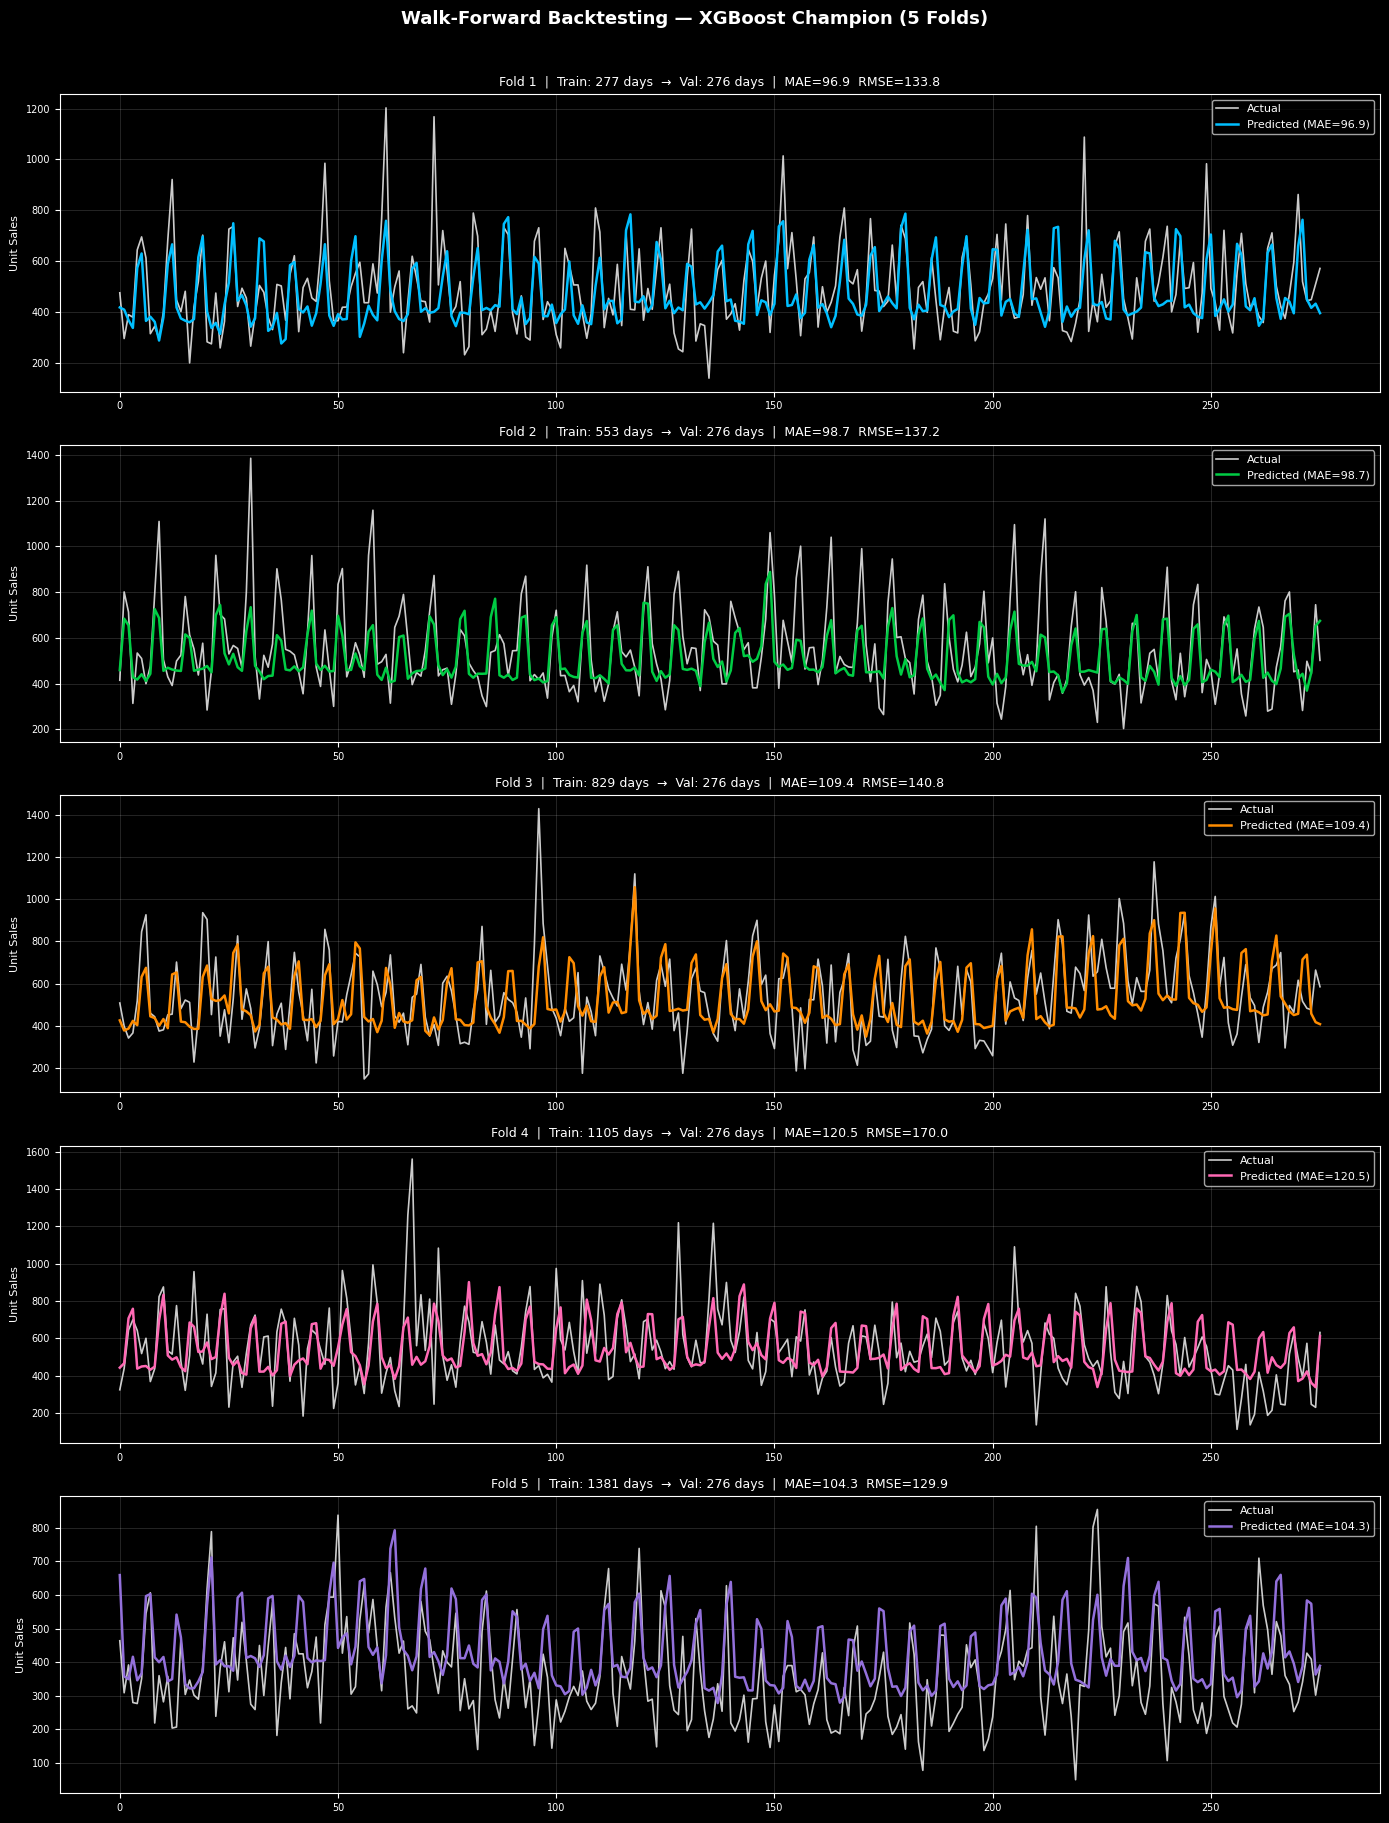


=== BACKTESTING SUMMARY — XGBoost Champion ===
 Fold  Train days  Val days    MAE   RMSE
    1         277       276  96.93 133.78
    2         553       276  98.69 137.21
    3         829       276 109.44 140.83
    4        1105       276 120.49 170.02
    5        1381       276 104.34 129.86

  Mean MAE  across folds: 105.98  ± 9.49
  Mean RMSE across folds: 142.34  ± 16.00

  Low std dev = model generalizes consistently across time ✓


In [21]:
# === 14. WALK-FORWARD BACKTESTING — TimeSeriesSplit Visualization ===

from sklearn.model_selection import TimeSeriesSplit

# ── Recreate features (same as section 2) ─────────────────────
def create_features(df):
    df = df.copy()
    df['day_of_week']     = df.index.dayofweek
    df['month']           = df.index.month
    df['day_of_month']    = df.index.day
    df['week_of_year']    = df.index.isocalendar().week.astype(int)
    df['is_weekend']      = (df.index.dayofweek >= 5).astype(int)
    df['quarter']         = df.index.quarter
    df['lag_1']           = df['unit_sales'].shift(1)
    df['lag_7']           = df['unit_sales'].shift(7)
    df['lag_14']          = df['unit_sales'].shift(14)
    df['lag_30']          = df['unit_sales'].shift(30)
    df['rolling_mean_7']  = df['unit_sales'].shift(1).rolling(7).mean()
    df['rolling_std_7']   = df['unit_sales'].shift(1).rolling(7).std()
    df['rolling_mean_14'] = df['unit_sales'].shift(1).rolling(14).mean()
    df.dropna(inplace=True)
    return df

df_feat  = create_features(ts_data)
FEATURES = [c for c in df_feat.columns if c != 'unit_sales']
TARGET   = 'unit_sales'

# ── Walk-forward backtesting ───────────────────────────────────
tscv_bt = TimeSeriesSplit(n_splits=5)
fold_results = []

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=False)
fig.suptitle('Walk-Forward Backtesting — XGBoost Champion (5 Folds)',
             fontsize=13, fontweight='bold', y=1.01)

colors_fold = ['#00BFFF', '#00CC44', '#FF8C00', '#FF69B4', '#9370DB']

for fold, (tr_idx, val_idx) in enumerate(tscv_bt.split(df_feat)):
    X_tr  = df_feat.iloc[tr_idx][FEATURES]
    y_tr  = df_feat.iloc[tr_idx][TARGET]
    X_val = df_feat.iloc[val_idx][FEATURES]
    y_val = df_feat.iloc[val_idx][TARGET]

    fold_model = XGBRegressor(objective='reg:squarederror',
                               random_state=42, **best_xgb_params)
    fold_model.fit(X_tr, y_tr)
    fold_preds = fold_model.predict(X_val)

    fold_mae  = mean_absolute_error(y_val, fold_preds)
    fold_rmse = np.sqrt(mean_squared_error(y_val, fold_preds))
    fold_results.append({'Fold': fold + 1,
                         'Train days': len(tr_idx),
                         'Val days':   len(val_idx),
                         'MAE':        round(fold_mae, 2),
                         'RMSE':       round(fold_rmse, 2)})

    ax = axes[fold]
    ax.plot(y_val.values,  label='Actual',
            color='white', alpha=0.8, lw=1.2)
    ax.plot(fold_preds,    label=f'Predicted (MAE={fold_mae:.1f})',
            color=colors_fold[fold], lw=1.8)
    ax.set_title(f'Fold {fold+1}  |  Train: {len(tr_idx)} days  →  Val: {len(val_idx)} days  '
                 f'|  MAE={fold_mae:.1f}  RMSE={fold_rmse:.1f}',
                 color='white', fontsize=9)
    ax.set_ylabel('Unit Sales', color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)
    for spine in ax.spines.values():
        spine.set_color('white')

plt.tight_layout()
plt.show()

df_bt = pd.DataFrame(fold_results)
print("\n=== BACKTESTING SUMMARY — XGBoost Champion ===")
print(df_bt.to_string(index=False))
print(f"\n  Mean MAE  across folds: {df_bt['MAE'].mean():.2f}  ± {df_bt['MAE'].std():.2f}")
print(f"  Mean RMSE across folds: {df_bt['RMSE'].mean():.2f}  ± {df_bt['RMSE'].std():.2f}")
print(f"\n  Low std dev = model generalizes consistently across time ✓")
